# ACTUWISE — Module 3 · Notebook 3.1
## Analyse de la Sinistralité Individuelle — EDA Pré-Modélisation

**Projet :** ACTUWISE — Plateforme d'Analyse Actuarielle, Assurance Non-Vie (Automobile Tunisie)  
**Données :** `dataset_frequence.csv` (94 852 obs.) · `dataset_severite.csv` (64 603 obs.)  
**Objectif :** Explorer et comprendre les données jointes avant toute modélisation GLM/XGBoost/CANN  

---

### Pipeline du Notebook 3.1

```
dataset_frequence.csv  ──┐
                          ├──► EDA variables cibles ──► Analyse segments ──► Corrélations ──► Insights métier
dataset_severite.csv   ──┘
```

**Livrables produits ici :**
- Identification des variables les plus discriminantes → Notebook 3.2 (GLM)
- Segments à risque élevé / ratio combiné → Notebook 3.3 (XGBoost)
- Profils types (risqué / moyen / bon risque) → Notebook 3.4 (SHAP)

## 1. Imports et Configuration

Toutes les librairies utilisées dans ce notebook sont standards en data science actuarielle.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Palette ACTUWISE ──────────────────────────────────────────────────
C1 = '#1a3c6e'  # bleu marine — couleur principale
C2 = '#1a7a6a'  # vert actuariel
C3 = '#c0392b'  # rouge alerte
C4 = '#e67e22'  # orange warning
C5 = '#8e44ad'  # violet ML
PALETTE = [C1, C2, C3, C4, C5]

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans'
})

print('✅ Configuration ACTUWISE chargée')
print(f'Palette : {PALETTE}')

✅ Configuration ACTUWISE chargée
Palette : ['#1a3c6e', '#1a7a6a', '#c0392b', '#e67e22', '#8e44ad']


## 2. Chargement des Données

Les deux datasets sont produits par **Notebook 3** (jointure LEFT JOIN entre Base Production et Base Sinistres).  
- `dataset_frequence.csv` : 94 852 observations — **toutes les polices**, y compris celles sans sinistre  
- `dataset_severite.csv` : 64 603 observations — **uniquement les polices avec au moins un sinistre**

In [4]:
# ── Chargement ────────────────────────────────────────────────────────
df_freq = pd.read_csv('dataset_module3_frequence.csv')
df_sev  = pd.read_csv('dataset_module3_severite.csv')

print('=== dataset_module3_frequence.csv ===')
print(f'  Lignes : {len(df_freq):,} | Colonnes : {df_freq.shape[1]}')
print(f'  Mémoire : {df_freq.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print()
print('=== dataset_module3_severite.csv ===')
print(f'  Lignes : {len(df_sev):,} | Colonnes : {df_sev.shape[1]}')
print(f'  Mémoire : {df_sev.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print()
print('─' * 60)
print(f'Taux de sinistralité global : {len(df_sev)/len(df_freq)*100:.1f}% des polices ont eu un sinistre')
print(f'Polices sans sinistre       : {len(df_freq) - len(df_sev):,} ({(1 - len(df_sev)/len(df_freq))*100:.1f}%)')

=== dataset_module3_frequence.csv ===
  Lignes : 94,846 | Colonnes : 31
  Mémoire : 23.5 MB

=== dataset_module3_severite.csv ===
  Lignes : 39,873 | Colonnes : 31
  Mémoire : 9.9 MB

────────────────────────────────────────────────────────────
Taux de sinistralité global : 42.0% des polices ont eu un sinistre
Polices sans sinistre       : 54,973 (58.0%)


In [5]:
# ── Aperçu dataset_frequence ──────────────────────────────────────────
print('\n--- Colonnes dataset_frequence ---')
print(df_freq.dtypes.to_string())
print('\n--- 5 premières lignes ---')
df_freq.head()


--- Colonnes dataset_frequence ---
age_conducteur                float64
age_manquant                    int64
sexe_masculin                   int64
Puissance fiscale               int64
anciennete_vehicule           float64
Valeur venale                 float64
Classe BM                       int64
bm_normalise                  float64
exposition                    float64
region_freq                   float64
marque_freq                   float64
score_risque                  float64
log_prime_annuelle            float64
log_valeur_venale             float64
ratio_prime_valeur            float64
tranche_age                   float64
Usage_Promenade et affaire      int64
Usage_Utilitaire I              int64
Energie_Essence                 int64
Energie_Diesel                  int64
nb_sinistres_total            float64
freq_hist_3ans                float64
a_eu_corporel                   int64
a_dossier_ouvert              float64
tendance_sinistres            float64
cout_moy_hist 

,age_conducteur,age_manquant,sexe_masculin,Puissance fiscale,anciennete_vehicule,Valeur venale,Classe BM,bm_normalise,exposition,region_freq,...,freq_hist_3ans,a_eu_corporel,a_dossier_ouvert,tendance_sinistres,cout_moy_hist,ratio_sinistres_prime,log_cout_total,a_eu_sinistre,exposition.1,POL_FILLE
0,48.8,0,0,6,10.0,70000.0,1,0.0,0.024641,0.170972,...,0.000000,0,0.0,0.0,0.00000,0.000000,0.000000,0,0.024641,101120003475
1,33.6,0,0,7,10.0,89900.0,3,0.2,0.402464,0.049298,...,0.333333,0,1.0,1.0,0.00000,0.000000,0.000000,1,0.402464,101190002475
2,49.0,0,0,5,10.0,56950.0,1,0.0,0.511978,0.170972,...,0.000000,0,0.0,0.0,6.16323,2.170653,6.855323,1,0.511978,101060001517
3,37.4,0,1,6,10.0,95000.0,8,0.7,0.177960,0.124584,...,0.000000,0,0.0,0.0,0.00000,0.000000,0.000000,0,0.177960,101220003030
4,47.7,0,0,8,10.0,168000.0,2,0.1,0.134155,0.079513,...,0.000000,0,0.0,0.0,0.00000,0.000000,0.000000,0,0.134155,101190003172


In [6]:
# ── Aperçu dataset_severite ───────────────────────────────────────────
print('\n--- Colonnes dataset_severite ---')
print(df_sev.dtypes.to_string())
print('\n--- 5 premières lignes ---')
df_sev.head()


--- Colonnes dataset_severite ---
age_conducteur                float64
age_manquant                    int64
sexe_masculin                   int64
Puissance fiscale               int64
anciennete_vehicule           float64
Valeur venale                 float64
Classe BM                       int64
bm_normalise                  float64
exposition                    float64
region_freq                   float64
marque_freq                   float64
score_risque                  float64
log_prime_annuelle            float64
log_valeur_venale             float64
ratio_prime_valeur            float64
tranche_age                   float64
Usage_Promenade et affaire      int64
Usage_Utilitaire I              int64
Energie_Essence                 int64
Energie_Diesel                  int64
nb_sinistres_total            float64
freq_hist_3ans                float64
a_eu_corporel                   int64
a_dossier_ouvert              float64
tendance_sinistres            float64
cout_moy_hist  

,age_conducteur,age_manquant,sexe_masculin,Puissance fiscale,anciennete_vehicule,Valeur venale,Classe BM,bm_normalise,exposition,region_freq,...,freq_hist_3ans,a_eu_corporel,a_dossier_ouvert,tendance_sinistres,cout_moy_hist,ratio_sinistres_prime,log_cout_total,severite_sinistres,POL_FILLE,log_severite
0,49.0,0,0,5,10.0,56950.0,1,0.0,0.511978,0.170972,...,0.000000,0,0.0,0.0,6.163230,2.170653,6.855323,473.9595,101060001517,6.163230
1,56.2,0,1,7,10.0,86000.0,2,0.1,0.544832,0.049298,...,0.000000,0,0.0,-2.0,3.599447,0.113095,4.278830,35.5780,101170001557,3.599447
2,50.5,0,1,5,10.0,68900.0,1,0.0,0.449008,0.270379,...,0.000000,0,1.0,0.0,3.791007,0.136988,3.791007,43.3010,101090002449,3.791007
3,51.6,0,0,6,10.0,84980.0,1,0.0,0.752909,0.124584,...,0.333333,0,0.0,0.0,8.221842,5.000000,8.221842,3720.3500,101190000856,8.221842
4,52.4,0,0,4,10.0,33809.0,1,0.0,0.676249,0.270379,...,0.000000,0,0.0,0.0,6.857514,3.052089,6.857514,950.0000,101110001301,6.857514


In [7]:
# ── Statistiques descriptives globales ────────────────────────────────
print('=== Statistiques dataset_frequence (variables cibles) ===')

# Colonnes cibles probables — adapter si noms différents
cols_freq_cible = [c for c in df_freq.columns if c in [
    'a_eu_sinistre', 'nb_sinistres', 'frequence_sinistres',
    'exposition', 'loss_ratio'
]]
print(df_freq[cols_freq_cible].describe().round(4).to_string())

print('\n=== Statistiques dataset_severite (variables cibles) ===')
cols_sev_cible = [c for c in df_sev.columns if c in [
    'severite_sinistres', 'cout_total', 'cout_moyen',
    'log_severite', 'loss_ratio'
]]
print(df_sev[cols_sev_cible].describe().round(4).to_string())

=== Statistiques dataset_frequence (variables cibles) ===
       exposition  a_eu_sinistre
count  94846.0000     94846.0000
mean       3.4023         0.4904
std        2.0355         0.4999
min        0.0100         0.0000
25%        1.6181         0.0000
50%        3.3128         0.0000
75%        5.1718         1.0000
max        7.5400         1.0000

=== Statistiques dataset_severite (variables cibles) ===
       severite_sinistres  log_severite
count          39873.0000    39873.0000
mean            1083.7130        5.6879
std             3334.2636        1.5664
min                7.2508        2.1103
25%               72.3110        4.2947
50%              279.9777        5.6383
75%              940.2690        6.8472
max           106082.1975       11.5720


## 3. Distribution des Variables Cibles — Fréquence

**Référence métier :** La fréquence des sinistres suit typiquement une loi de **Poisson** en assurance Non-Vie.  
La variable binaire `a_eu_sinistre` (0/1) et la fréquence continue `frequence_sinistres = nb_sinistres / exposition`  
sont les deux formes de la variable cible utilisées dans les modèles.  

> *McCullagh & Nelder (1989), Generalized Linear Models — Chapitre sur la régression de Poisson avec offset*

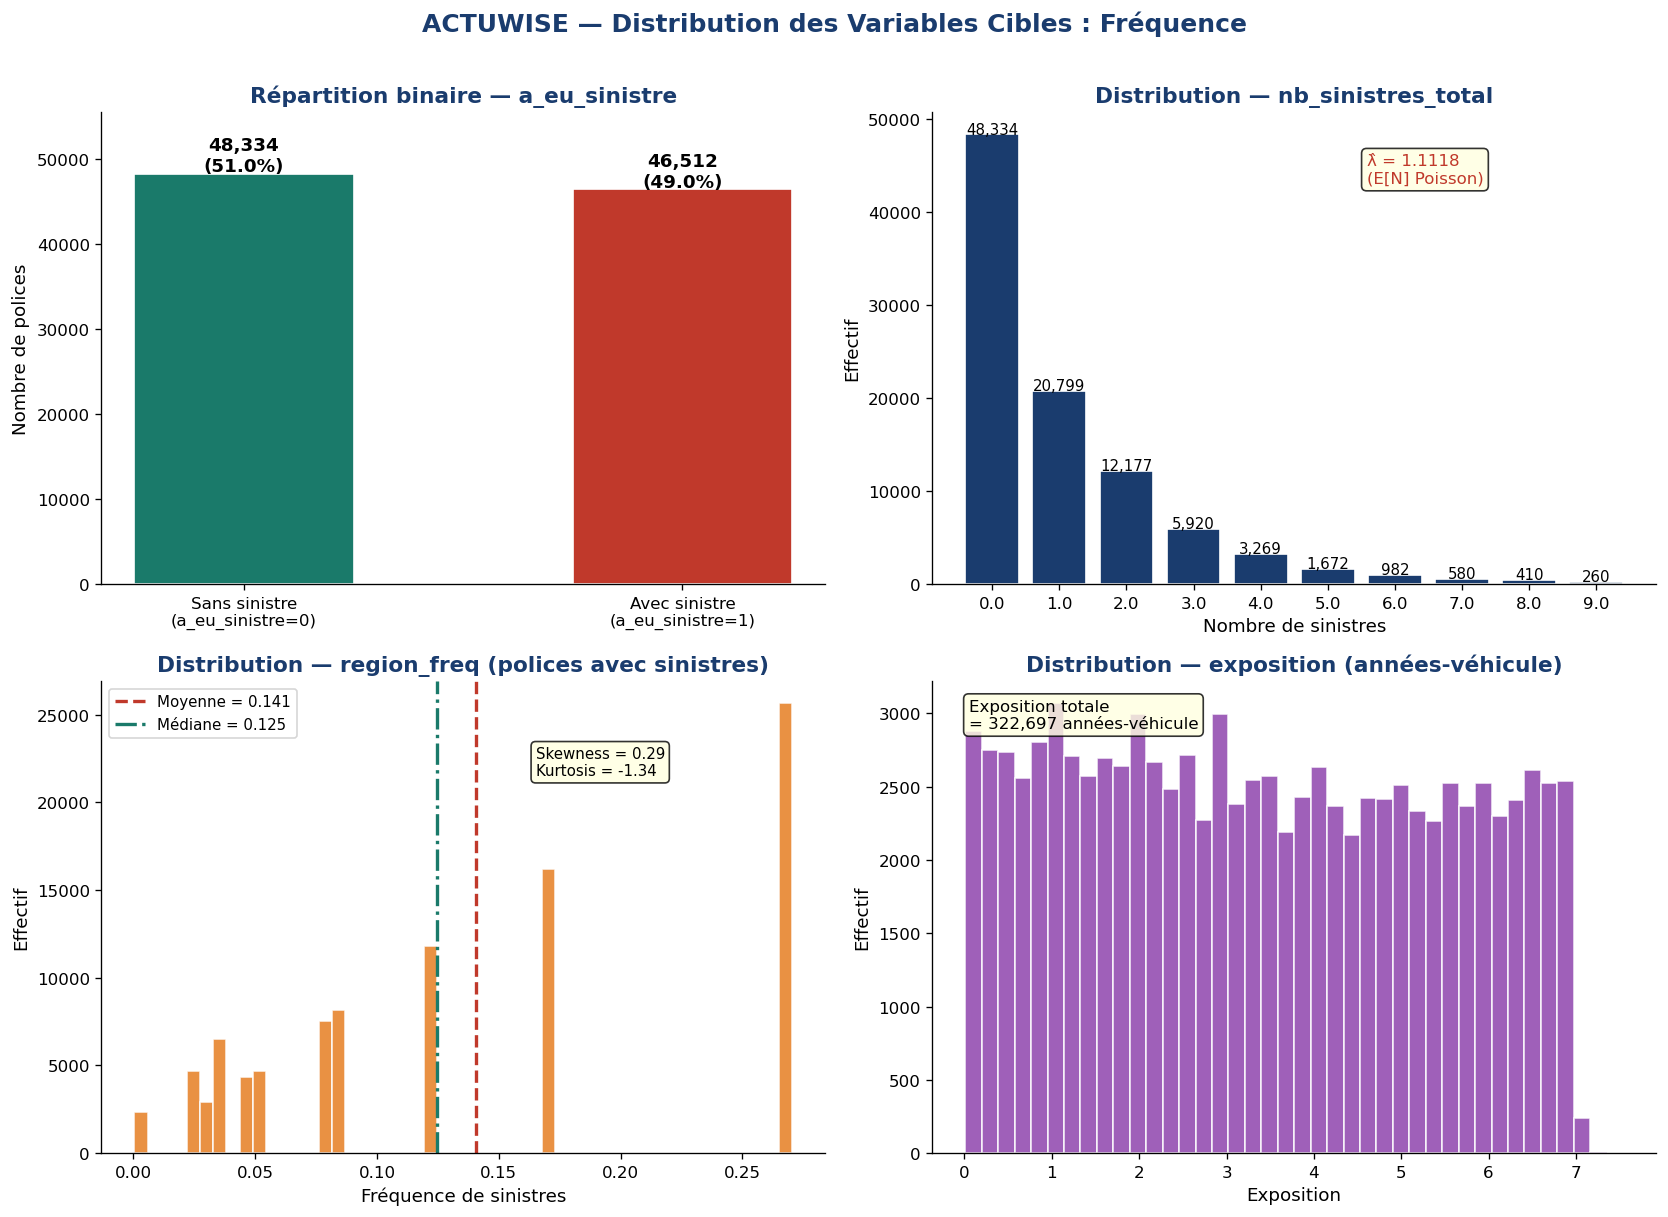

✅ Figure sauvegardée : fig_31_frequence_distribution.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ACTUWISE — Distribution des Variables Cibles : Fréquence', fontsize=15, fontweight='bold', color=C1, y=1.01)

# ── Détection automatique des colonnes ────────────────────────────────
col_bin   = next((c for c in df_freq.columns if 'sinistre' in c.lower() and df_freq[c].nunique() == 2), None)
col_freq  = next((c for c in df_freq.columns if 'frequence' in c.lower() or 'freq' in c.lower()), None)
col_nb    = next((c for c in df_freq.columns if 'nb_sinistre' in c.lower() or 'nombre' in c.lower()), None)
col_expo  = next((c for c in df_freq.columns if 'exposition' in c.lower() or 'expo' in c.lower()), None)

# ── Graphe 1 : Proportion sinistré / non sinistré ─────────────────────
ax = axes[0, 0]
if col_bin:
    counts = df_freq[col_bin].value_counts()
    bars = ax.bar(['Sans sinistre\n(a_eu_sinistre=0)', 'Avec sinistre\n(a_eu_sinistre=1)'],
                  counts.sort_index().values, color=[C2, C3], edgecolor='white', width=0.5)
    for bar, v in zip(bars, counts.sort_index().values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                f'{v:,}\n({v/len(df_freq)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
    ax.set_title(f'Répartition binaire — {col_bin}', fontweight='bold', color=C1)
    ax.set_ylabel('Nombre de polices')
    ax.set_ylim(0, counts.max() * 1.15)
else:
    ax.text(0.5, 0.5, 'Colonne a_eu_sinistre\nnon trouvée', ha='center', va='center', transform=ax.transAxes)

# ── Graphe 2 : Distribution nb_sinistres ──────────────────────────────
ax = axes[0, 1]
if col_nb:
    vc = df_freq[col_nb].value_counts().sort_index().head(10)
    bars = ax.bar(vc.index.astype(str), vc.values, color=C1, edgecolor='white')
    for bar, v in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'{v:,}', ha='center', fontsize=9)
    ax.set_title(f'Distribution — {col_nb}', fontweight='bold', color=C1)
    ax.set_xlabel('Nombre de sinistres')
    ax.set_ylabel('Effectif')

    # Test goodness-of-fit Poisson
    lambda_hat = df_freq[col_nb].mean()
    ax.text(0.6, 0.85, f'λ̂ = {lambda_hat:.4f}\n(E[N] Poisson)', transform=ax.transAxes,
            fontsize=10, color=C3, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
else:
    ax.text(0.5, 0.5, 'Colonne nb_sinistres\nnon trouvée', ha='center', va='center', transform=ax.transAxes)

# ── Graphe 3 : Distribution fréquence continue ────────────────────────
ax = axes[1, 0]
if col_freq:
    data_plot = df_freq[col_freq].dropna()
    data_plot = data_plot[data_plot > 0]  # polices avec sinistres
    ax.hist(data_plot, bins=50, color=C4, edgecolor='white', alpha=0.85)
    ax.axvline(data_plot.mean(), color=C3, linewidth=2, linestyle='--', label=f'Moyenne = {data_plot.mean():.3f}')
    ax.axvline(data_plot.median(), color=C2, linewidth=2, linestyle='-.', label=f'Médiane = {data_plot.median():.3f}')
    ax.set_title(f'Distribution — {col_freq} (polices avec sinistres)', fontweight='bold', color=C1)
    ax.set_xlabel('Fréquence de sinistres')
    ax.set_ylabel('Effectif')
    ax.legend(fontsize=9)
    skew = data_plot.skew()
    ax.text(0.6, 0.8, f'Skewness = {skew:.2f}\nKurtosis = {data_plot.kurtosis():.2f}',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
else:
    ax.text(0.5, 0.5, 'Colonne frequence_sinistres\nnon trouvée', ha='center', va='center', transform=ax.transAxes)

# ── Graphe 4 : Exposition ─────────────────────────────────────────────
ax = axes[1, 1]
if col_expo:
    ax.hist(df_freq[col_expo].dropna(), bins=40, color=C5, edgecolor='white', alpha=0.85)
    ax.set_title(f'Distribution — {col_expo} (années-véhicule)', fontweight='bold', color=C1)
    ax.set_xlabel('Exposition')
    ax.set_ylabel('Effectif')
    total_expo = df_freq[col_expo].sum()
    ax.text(0.05, 0.9, f'Exposition totale\n= {total_expo:,.0f} années-véhicule',
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
else:
    ax.text(0.5, 0.5, 'Colonne exposition\nnon trouvée', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig('fig_31_frequence_distribution.png', bbox_inches='tight', dpi=120)
plt.show()
print('✅ Figure sauvegardée : fig_31_frequence_distribution.png')

## 4. Distribution des Variables Cibles — Sévérité

**Référence métier :** Le coût moyen des sinistres suit typiquement une loi **Gamma** ou **Log-Normale**  
en assurance automobile (queues lourdes, toujours positive).  
La transformation `log_severite = log(severite_sinistres)` est utilisée pour **symétriser** la distribution  
et améliorer le comportement des modèles de régression.  

> *Ohlsson & Johansson (2010), Non-Life Insurance Pricing with Generalized Linear Models — Chapitre 3 : Gamma GLM*

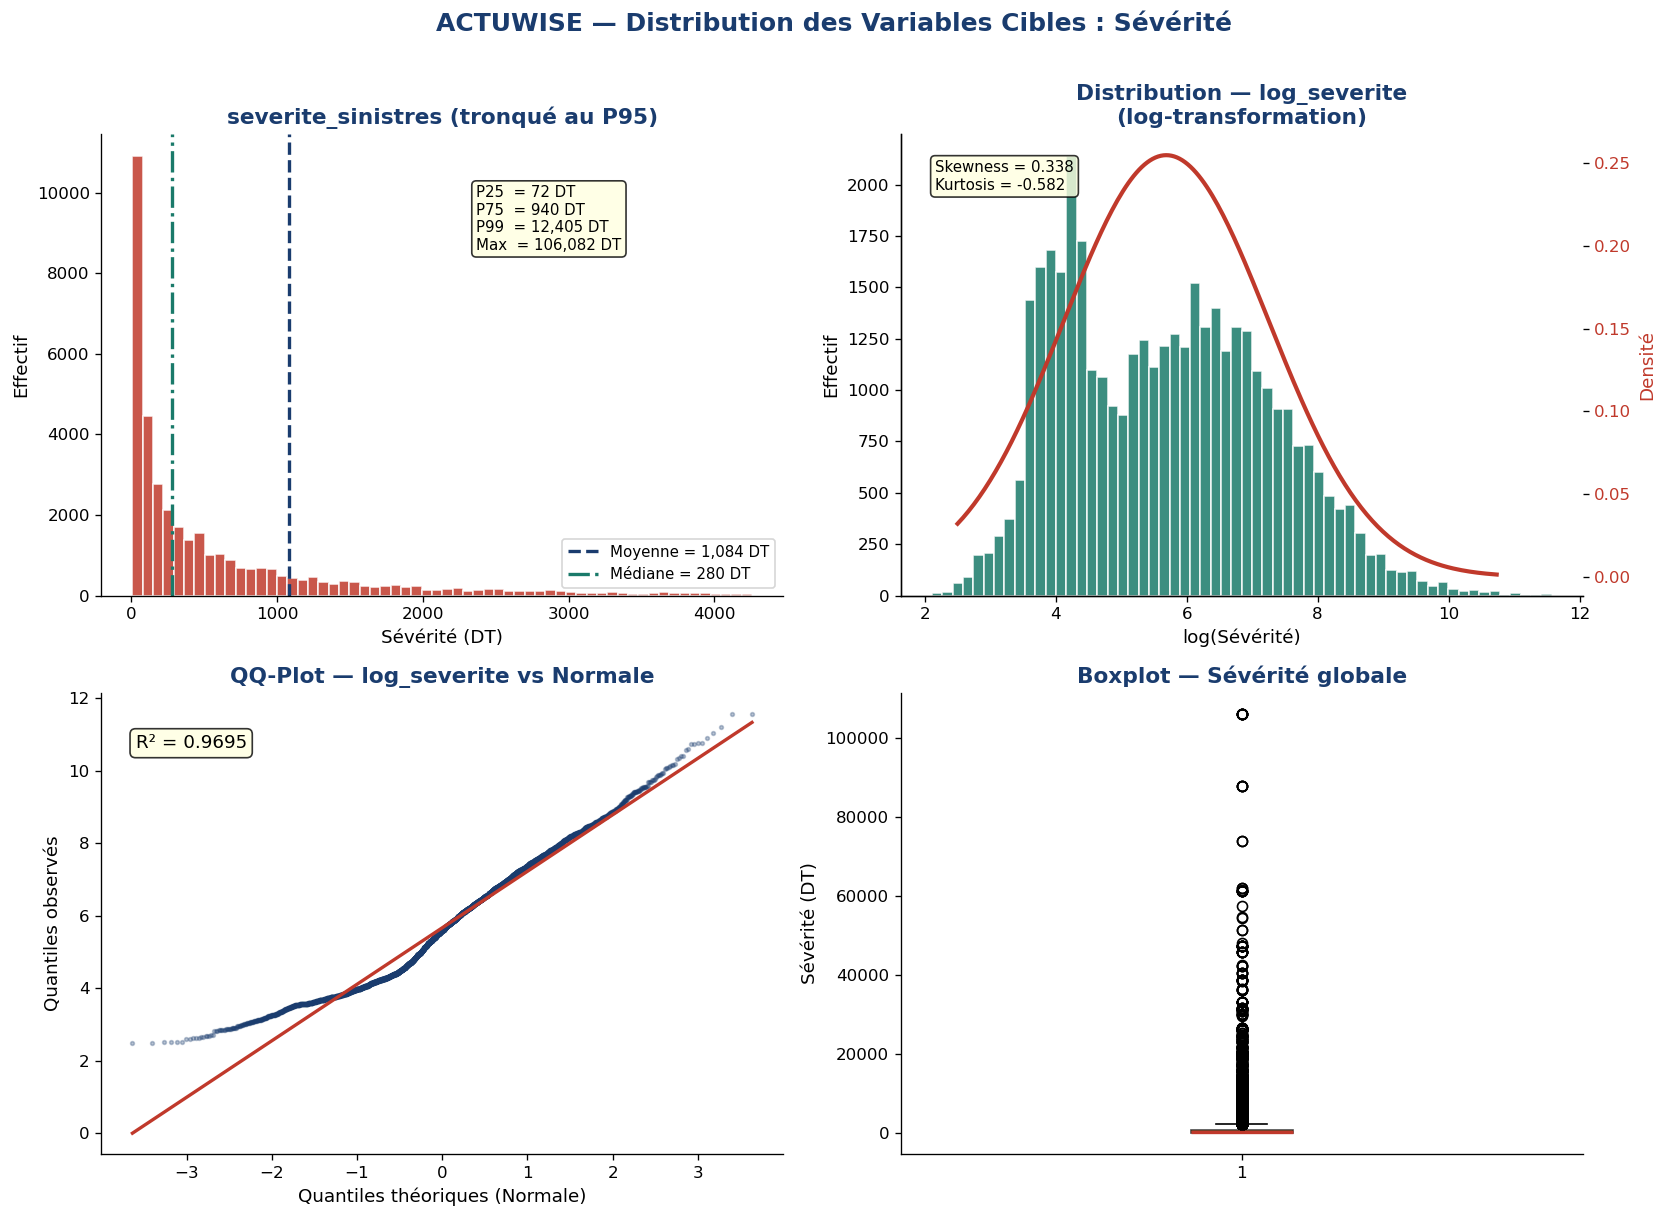

✅ Figure sauvegardée : fig_31_severite_distribution.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ACTUWISE — Distribution des Variables Cibles : Sévérité', fontsize=15, fontweight='bold', color=C1, y=1.01)

col_sev     = next((c for c in df_sev.columns if 'severite' in c.lower() and 'log' not in c.lower()), None)
col_log_sev = next((c for c in df_sev.columns if 'log' in c.lower() and 'sev' in c.lower()), None)
col_cout    = next((c for c in df_sev.columns if 'cout' in c.lower() or 'montant' in c.lower()), None)

# Fallback si log_severite absent
if col_sev and not col_log_sev:
    df_sev['log_severite'] = np.log(df_sev[col_sev].replace(0, np.nan))
    col_log_sev = 'log_severite'

# ── Graphe 1 : Distribution sévérité brute ────────────────────────────
ax = axes[0, 0]
if col_sev:
    data = df_sev[col_sev].dropna()
    data = data[data > 0]
    p95 = data.quantile(0.95)
    ax.hist(data[data <= p95], bins=60, color=C3, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color=C1, lw=2, ls='--', label=f'Moyenne = {data.mean():,.0f} DT')
    ax.axvline(data.median(), color=C2, lw=2, ls='-.', label=f'Médiane = {data.median():,.0f} DT')
    ax.set_title(f'{col_sev} (tronqué au P95)', fontweight='bold', color=C1)
    ax.set_xlabel('Sévérité (DT)')
    ax.set_ylabel('Effectif')
    ax.legend(fontsize=9)
    ax.text(0.55, 0.75,
            f'P25  = {data.quantile(.25):,.0f} DT\nP75  = {data.quantile(.75):,.0f} DT\nP99  = {data.quantile(.99):,.0f} DT\nMax  = {data.max():,.0f} DT',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
else:
    ax.text(0.5, 0.5, 'Colonne sévérité non trouvée', ha='center', va='center', transform=ax.transAxes)

# ── Graphe 2 : log_severite ───────────────────────────────────────────
ax = axes[0, 1]
if col_log_sev:
    data_log = df_sev[col_log_sev].dropna()
    data_log = data_log[np.isfinite(data_log)]
    ax.hist(data_log, bins=60, color=C2, edgecolor='white', alpha=0.85)
    # Fit normale
    mu, sigma = data_log.mean(), data_log.std()
    xmin, xmax = data_log.quantile(0.001), data_log.quantile(0.999)
    x = np.linspace(xmin, xmax, 200)
    ax2 = ax.twinx()
    ax2.plot(x, stats.norm.pdf(x, mu, sigma), color=C3, lw=2.5, label=f'N({mu:.2f}, {sigma:.2f})')
    ax2.set_ylabel('Densité', color=C3)
    ax2.tick_params(axis='y', labelcolor=C3)
    ax.set_title(f'Distribution — {col_log_sev}\n(log-transformation)', fontweight='bold', color=C1)
    ax.set_xlabel('log(Sévérité)')
    ax.set_ylabel('Effectif')
    ax.text(0.05, 0.88, f'Skewness = {data_log.skew():.3f}\nKurtosis = {data_log.kurtosis():.3f}',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ── Graphe 3 : QQ-plot log_severite ───────────────────────────────────
ax = axes[1, 0]
if col_log_sev:
    sample = df_sev[col_log_sev].dropna()
    sample = sample[np.isfinite(sample)]
    if len(sample) > 5000:
        sample = sample.sample(5000, random_state=42)
    (osm, osr), (slope, intercept, r) = stats.probplot(sample, dist='norm')
    ax.scatter(osm, osr, color=C1, alpha=0.3, s=5)
    ax.plot([min(osm), max(osm)],
            [slope*min(osm)+intercept, slope*max(osm)+intercept],
            color=C3, lw=2)
    ax.set_title('QQ-Plot — log_severite vs Normale', fontweight='bold', color=C1)
    ax.set_xlabel('Quantiles théoriques (Normale)')
    ax.set_ylabel('Quantiles observés')
    ax.text(0.05, 0.88, f'R² = {r**2:.4f}', transform=ax.transAxes, fontsize=11,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ── Graphe 4 : Boxplot sévérité par type de sinistre ──────────────────
ax = axes[1, 1]
col_type = next((c for c in df_sev.columns if 'type' in c.lower() or 'nature' in c.lower() or 'garantie' in c.lower()), None)
if col_type and col_sev:
    groups = df_sev.groupby(col_type)[col_sev].apply(lambda x: x[x > 0].dropna())
    top_groups = df_sev[col_type].value_counts().head(6).index
    data_box = [df_sev.loc[df_sev[col_type] == g, col_sev].dropna().values for g in top_groups]
    bp = ax.boxplot(data_box, patch_artist=True, notch=False,
                    medianprops=dict(color=C3, linewidth=2))
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticks(range(1, len(top_groups)+1))
    ax.set_xticklabels([str(g)[:12] for g in top_groups], rotation=20, ha='right', fontsize=9)
    ax.set_title(f'Sévérité par {col_type}', fontweight='bold', color=C1)
    ax.set_ylabel('Sévérité (DT)')
    ax.set_yscale('log')
elif col_sev:
    # Boxplot simple
    ax.boxplot(df_sev[col_sev].dropna().values, patch_artist=True,
               boxprops=dict(facecolor=C4, alpha=0.7),
               medianprops=dict(color=C3, lw=2))
    ax.set_title('Boxplot — Sévérité globale', fontweight='bold', color=C1)
    ax.set_ylabel('Sévérité (DT)')

plt.tight_layout()
plt.savefig('fig_31_severite_distribution.png', bbox_inches='tight', dpi=120)
plt.show()
print('✅ Figure sauvegardée : fig_31_severite_distribution.png')

## 5. Analyse du Loss Ratio par Segment

Le **loss ratio** (ratio sinistres / primes) est l'indicateur central de rentabilité par segment.  
Il permet d'identifier les combinaisons **Usage × Énergie × Région** sur-sinistrantess ou sous-tarifées.  

**Seuil critique :** Un loss ratio > 70% signale une dégradation technique (ratio combiné > 100% une fois les frais inclus).  

> *Formule : Loss Ratio_s = Sinistres_s / Primes_s*

In [10]:
# ── Détection colonnes segment ────────────────────────────────────────
col_usage   = next((c for c in df_freq.columns if 'usage' in c.lower()), None)
col_energie = next((c for c in df_freq.columns if 'energ' in c.lower() or 'carburant' in c.lower()), None)
col_region  = next((c for c in df_freq.columns if 'region' in c.lower() or 'wilaya' in c.lower() or 'zone' in c.lower()), None)
col_lr      = next((c for c in df_freq.columns if 'loss_ratio' in c.lower() or 'lr' == c.lower()), None)
col_primes  = next((c for c in df_freq.columns if 'prime' in c.lower()), None)
col_sins    = next((c for c in df_freq.columns if 'cout_total' in c.lower() or 'sinistre' in c.lower() and 'cout' in c.lower()), None)

# Calculer loss ratio si absent
if col_lr is None and col_primes and col_sins:
    df_freq['loss_ratio'] = df_freq[col_sins] / df_freq[col_primes].replace(0, np.nan)
    col_lr = 'loss_ratio'
    print(f'✅ loss_ratio calculé depuis {col_sins} / {col_primes}')

segs_disponibles = [c for c in [col_usage, col_energie, col_region] if c]
print(f'Colonnes segment identifiées : {segs_disponibles}')
print(f'Colonne loss ratio           : {col_lr}')
print(f'Colonne primes               : {col_primes}')

✅ loss_ratio calculé depuis log_cout_total / log_prime_annuelle
Colonnes segment identifiées : ['Usage_Promenade et affaire', 'Energie_Essence', 'region_freq']
Colonne loss ratio           : loss_ratio
Colonne primes               : log_prime_annuelle


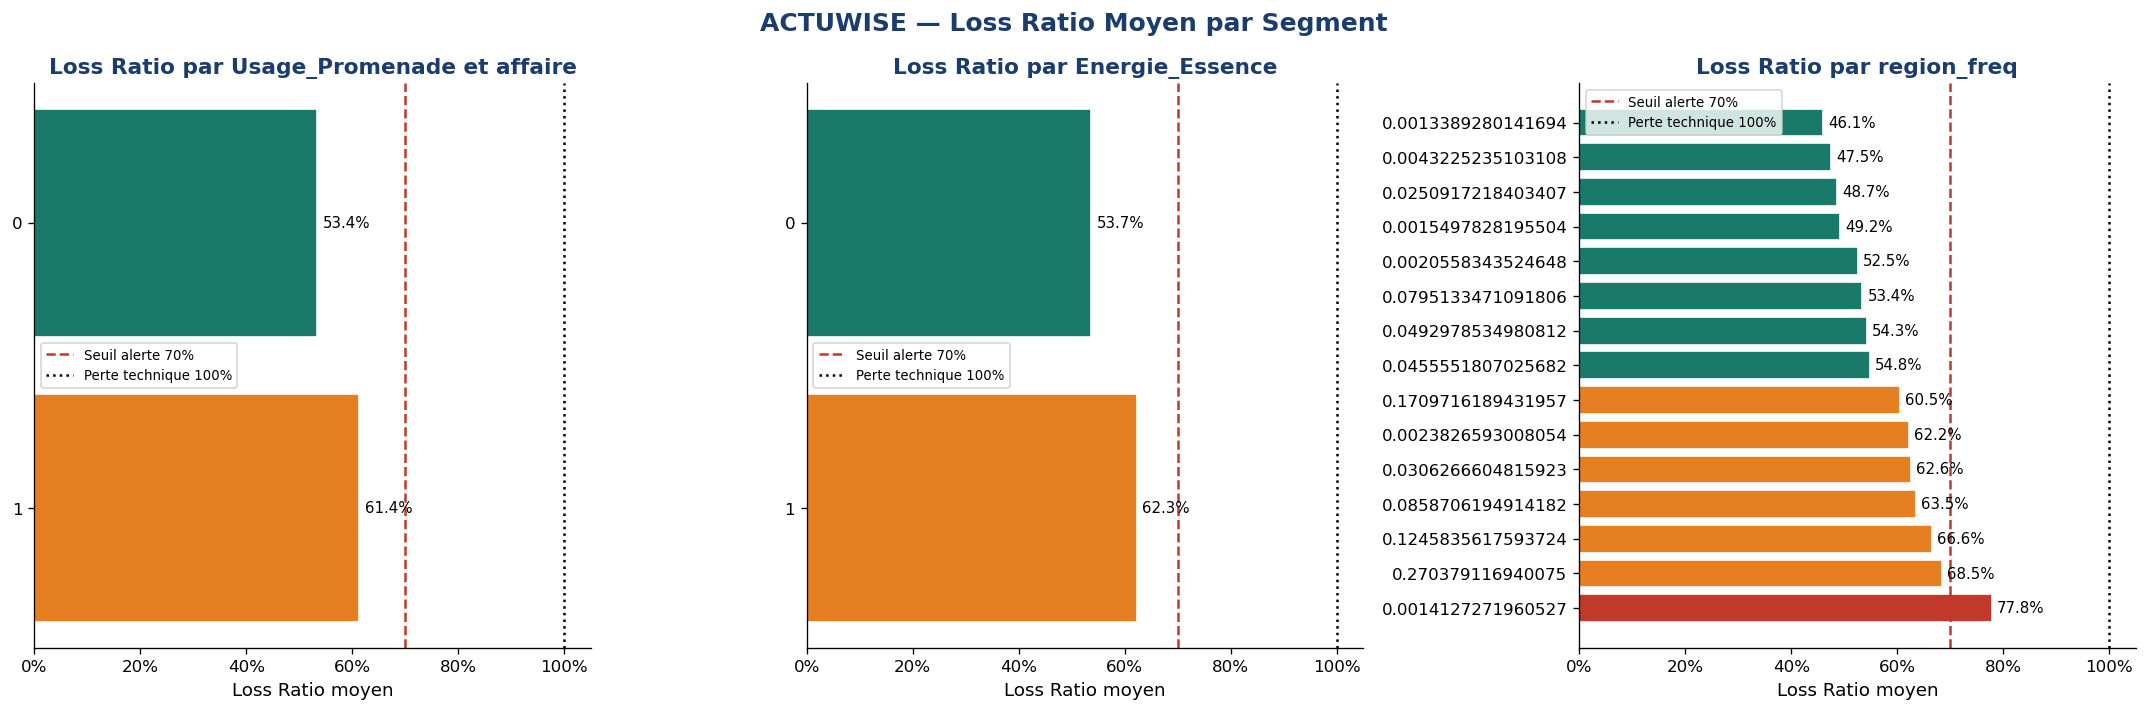

✅ Figure sauvegardée : fig_31_loss_ratio_segments.png


In [11]:
if col_lr and segs_disponibles:
    n_seg = len(segs_disponibles)
    fig, axes = plt.subplots(1, n_seg, figsize=(6*n_seg, 6))
    if n_seg == 1: axes = [axes]
    fig.suptitle('ACTUWISE — Loss Ratio Moyen par Segment', fontsize=15, fontweight='bold', color=C1)

    for ax, seg in zip(axes, segs_disponibles):
        lr_seg = (df_freq.groupby(seg)[col_lr]
                  .agg(['mean', 'count'])
                  .rename(columns={'mean': 'loss_ratio_moyen', 'count': 'n_polices'})
                  .sort_values('loss_ratio_moyen', ascending=False)
                  .head(15))

        colors = [C3 if lr > 0.70 else (C4 if lr > 0.60 else C2)
                  for lr in lr_seg['loss_ratio_moyen']]
        bars = ax.barh(lr_seg.index.astype(str), lr_seg['loss_ratio_moyen'], color=colors, edgecolor='white')

        # Ligne seuil 70%
        ax.axvline(0.70, color=C3, lw=1.5, linestyle='--', label='Seuil alerte 70%')
        ax.axvline(1.00, color='black', lw=1.5, linestyle=':', label='Perte technique 100%')

        for bar, (_, row) in zip(bars, lr_seg.iterrows()):
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                    f"{row['loss_ratio_moyen']*100:.1f}%", va='center', fontsize=9)

        ax.set_title(f'Loss Ratio par {seg}', fontweight='bold', color=C1)
        ax.set_xlabel('Loss Ratio moyen')
        ax.legend(fontsize=8)
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))

    plt.tight_layout()
    plt.savefig('fig_31_loss_ratio_segments.png', bbox_inches='tight', dpi=120)
    plt.show()
    print('✅ Figure sauvegardée : fig_31_loss_ratio_segments.png')
else:
    print('⚠️ Colonnes segment ou loss_ratio non détectées — vérifier les noms de colonnes')

## 6. Ratio Combiné par Segment et par Année

Le **ratio combiné** est l'indicateur de rentabilité technique le plus important en assurance Non-Vie :  

$$\text{Ratio combiné}_s = \frac{S_s + F_s}{P_s} = \underbrace{\frac{S_s}{P_s}}_{\text{ratio sinistres}} + \underbrace{\frac{F_s}{P_s}}_{\text{ratio frais}}$$

Dans cette analyse exploratoire, nous estimons le ratio combiné **brut** avec un ratio de frais forfaitaire de 25 %  
(hypothèse standard avant calibration module 3.2).  
Un segment avec ratio combiné > 100 % génère une **perte technique** : les primes ne couvrent pas les sinistres + frais.

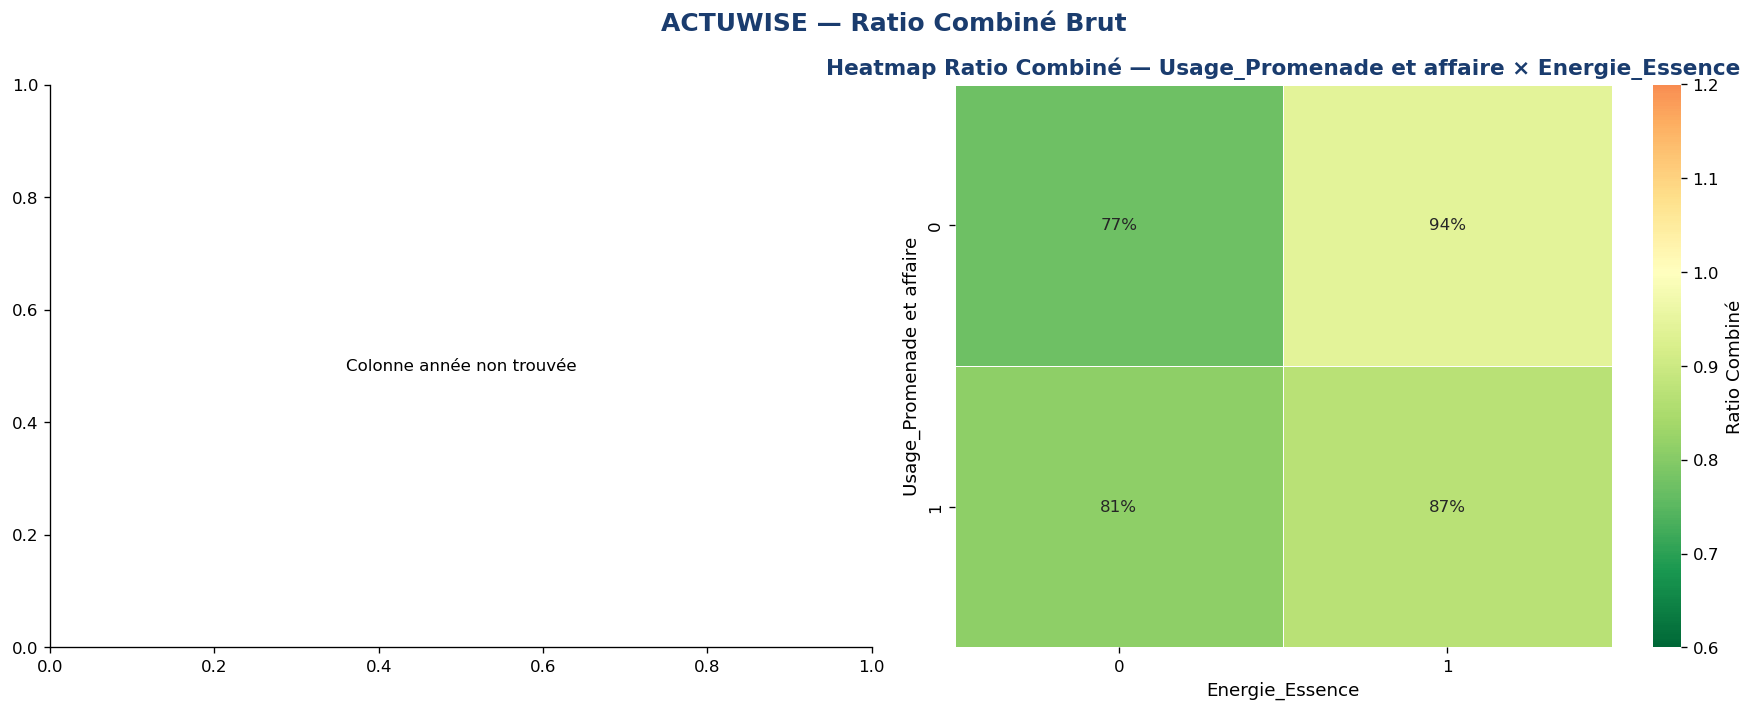

✅ Figure sauvegardée : fig_31_ratio_combine.png


In [12]:
# ── Calcul ratio combiné brut (frais = 25% forfaitaire) ───────────────
RATIO_FRAIS = 0.25

if col_lr is not None:
    df_freq['ratio_combine_brut'] = df_freq[col_lr] + RATIO_FRAIS

    # ── Par année ─────────────────────────────────────────────────────────
    col_annee = next((c for c in df_freq.columns if 'annee' in c.lower() or 'year' in c.lower() or 'an_' in c.lower()), None)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('ACTUWISE — Ratio Combiné Brut', fontsize=15, fontweight='bold', color=C1)

    # Graphe 1 : évolution par année
    ax = axes[0]
    if col_annee:
        rc_annee = df_freq.groupby(col_annee)['ratio_combine_brut'].mean()
        colors_bar = [C3 if rc > 1.0 else (C4 if rc > 0.95 else C2) for rc in rc_annee.values]
        bars = ax.bar(rc_annee.index.astype(str), rc_annee.values, color=colors_bar, edgecolor='white')
        ax.axhline(1.0, color='black', lw=2, linestyle='--', label='Seuil perte technique 100%')
        ax.axhline(0.95, color=C4, lw=1.5, linestyle=':', label='Seuil alerte 95%')
        for bar, val in zip(bars, rc_annee.values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{val*100:.1f}%', ha='center', fontsize=10, fontweight='bold')
        ax.set_title('Ratio Combiné brut par Année', fontweight='bold', color=C1)
        ax.set_xlabel('Année')
        ax.set_ylabel('Ratio Combiné')
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
        ax.legend(fontsize=9)
    else:
        ax.text(0.5, 0.5, 'Colonne année non trouvée', ha='center', va='center', transform=ax.transAxes)

    # Graphe 2 : heatmap ratio combiné par 2 segments
    ax = axes[1]
    if len(segs_disponibles) >= 2:
        seg1, seg2 = segs_disponibles[0], segs_disponibles[1]
        pivot = df_freq.pivot_table(values='ratio_combine_brut', index=seg1, columns=seg2, aggfunc='mean')
        sns.heatmap(pivot, ax=ax, cmap='RdYlGn_r', center=1.0, vmin=0.6, vmax=1.2,
                    annot=True, fmt='.0%', linewidths=0.5, cbar_kws={'label': 'Ratio Combiné'})
        ax.set_title(f'Heatmap Ratio Combiné — {seg1} × {seg2}', fontweight='bold', color=C1)
    elif segs_disponibles:
        rc_seg = df_freq.groupby(segs_disponibles[0])['ratio_combine_brut'].mean().sort_values(ascending=False)
        colors_bar = [C3 if rc > 1.0 else (C4 if rc > 0.95 else C2) for rc in rc_seg.values]
        ax.bar(rc_seg.index.astype(str), rc_seg.values, color=colors_bar, edgecolor='white')
        ax.axhline(1.0, color='black', lw=2, ls='--')
        ax.set_title(f'Ratio Combiné par {segs_disponibles[0]}', fontweight='bold', color=C1)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
        ax.tick_params(axis='x', rotation=30)
    else:
        ax.text(0.5, 0.5, 'Segments non disponibles', ha='center', va='center', transform=ax.transAxes)

    plt.tight_layout()
    plt.savefig('fig_31_ratio_combine.png', bbox_inches='tight', dpi=120)
    plt.show()
    print('✅ Figure sauvegardée : fig_31_ratio_combine.png')
else:
    print('⚠️ loss_ratio absent — ratio combiné non calculable')

## 7. Corrélations Features vs Cibles

Cette analyse identifie les variables explicatives les plus associées aux cibles de fréquence et de sévérité.  
Ces résultats guident directement la **sélection des features** dans les modèles GLM (Notebook 3.2)  
et XGBoost (Notebook 3.3).  

**Méthode :** Corrélation de Pearson (variables numériques) et Cramér's V (variables catégorielles).  
> *Le coefficient de corrélation ne capte que les relations linéaires — les modèles ML permettront de détecter les non-linéarités.*

In [13]:
# ── Corrélation Pearson : features numériques vs cibles ───────────────
num_cols = df_freq.select_dtypes(include=[np.number]).columns.tolist()

target_cols = [c for c in num_cols if any(kw in c.lower() for kw in
    ['frequence', 'freq', 'sinistre', 'loss_ratio', 'ratio'])]

feature_cols = [c for c in num_cols if c not in target_cols and
                not any(kw in c.lower() for kw in ['id', 'code', 'index'])]

print(f'Variables cibles identifiées  : {target_cols}')
print(f'Variables features numériques : {len(feature_cols)}')

Variables cibles identifiées  : ['region_freq', 'marque_freq', 'ratio_prime_valeur', 'nb_sinistres_total', 'freq_hist_3ans', 'tendance_sinistres', 'ratio_sinistres_prime', 'a_eu_sinistre', 'loss_ratio', 'ratio_combine_brut']
Variables features numériques : 23


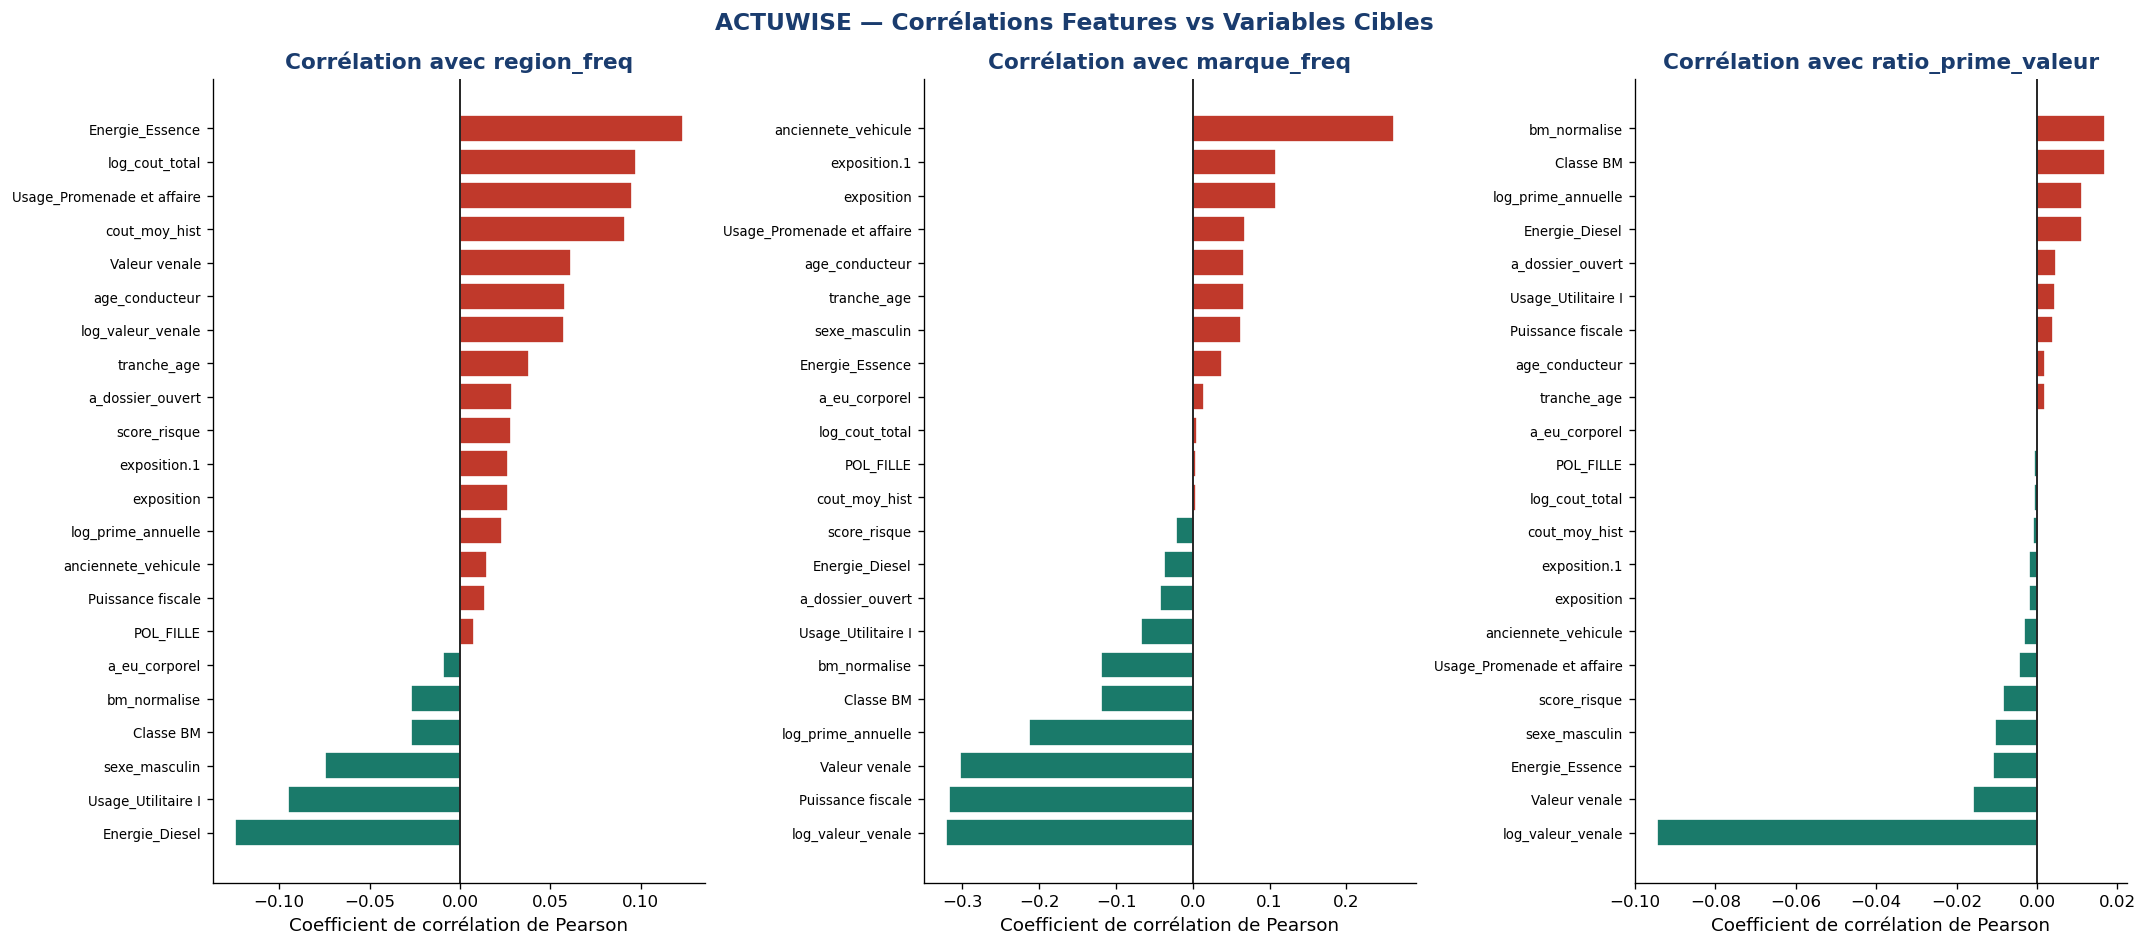

✅ Figure sauvegardée : fig_31_correlations.png


In [14]:
if target_cols and feature_cols:
    corr_matrix = df_freq[feature_cols + target_cols].corr()
    corr_with_targets = corr_matrix.loc[feature_cols, target_cols]

    fig, axes = plt.subplots(1, min(len(target_cols), 3), figsize=(6*min(len(target_cols), 3), 8))
    if len(target_cols) == 1: axes = [axes]

    fig.suptitle('ACTUWISE — Corrélations Features vs Variables Cibles', fontsize=14, fontweight='bold', color=C1)

    for ax, tgt in zip(axes, target_cols[:3]):
        corr_vals = corr_matrix.loc[feature_cols, tgt].dropna().sort_values()
        colors = [C3 if v > 0 else C2 for v in corr_vals.values]
        ax.barh(corr_vals.index, corr_vals.values, color=colors, edgecolor='white')
        ax.axvline(0, color='black', lw=1)
        ax.set_title(f'Corrélation avec {tgt}', fontweight='bold', color=C1)
        ax.set_xlabel('Coefficient de corrélation de Pearson')
        ax.tick_params(axis='y', labelsize=8)

    plt.tight_layout()
    plt.savefig('fig_31_correlations.png', bbox_inches='tight', dpi=120)
    plt.show()
    print('✅ Figure sauvegardée : fig_31_correlations.png')
else:
    print('⚠️ Colonnes insuffisantes pour la matrice de corrélation')

## 8. Variables les Plus Discriminantes

Identification des **5 variables les plus corrélées** avec chaque cible,  
via le coefficient de corrélation (numériques) et le test du Chi² (catégorielles).  
Ces variables constituent le **point de départ** des modèles GLM et XGBoost.

In [15]:
from scipy.stats import chi2_contingency

cat_cols = df_freq.select_dtypes(include=['object', 'category']).columns.tolist()

results = []

# Corrélations numériques
if target_cols and feature_cols:
    for tgt in target_cols:
        for feat in feature_cols:
            try:
                r = df_freq[[feat, tgt]].dropna().corr().iloc[0, 1]
                results.append({'variable': feat, 'cible': tgt, 'type': 'numérique',
                                 'association': abs(r), 'mesure': 'Pearson |r|'})
            except: pass

# Chi² catégorielles
if target_cols and cat_cols:
    for tgt in target_cols:
        if col_bin and tgt == col_bin: continue
        for feat in cat_cols:
            try:
                tab = pd.crosstab(df_freq[feat], df_freq[tgt].apply(lambda x: int(x > 0) if pd.notna(x) else np.nan))
                chi2, p, dof, _ = chi2_contingency(tab.dropna())
                n = tab.values.sum()
                k = min(tab.shape)
                cramers_v = np.sqrt(chi2 / (n * (k - 1))) if k > 1 else 0
                results.append({'variable': feat, 'cible': tgt, 'type': 'catégorielle',
                                 'association': cramers_v, 'mesure': 'Cramér V'})
            except: pass

if results:
    df_assoc = pd.DataFrame(results)
    print('=== TOP 10 variables les plus discriminantes ===')
    top10 = (df_assoc.groupby(['variable', 'mesure'])['association']
             .mean().reset_index()
             .sort_values('association', ascending=False)
             .head(10))
    print(top10.to_string(index=False))
else:
    print('⚠️ Analyse association non réalisable avec les colonnes disponibles')

=== TOP 10 variables les plus discriminantes ===
          variable      mesure  association
    log_cout_total Pearson |r|     0.450926
     cout_moy_hist Pearson |r|     0.436179
  a_dossier_ouvert Pearson |r|     0.201218
      score_risque Pearson |r|     0.175175
     a_eu_corporel Pearson |r|     0.103613
log_prime_annuelle Pearson |r|     0.103472
 log_valeur_venale Pearson |r|     0.086992
        exposition Pearson |r|     0.084979
      exposition.1 Pearson |r|     0.084979
     Valeur venale Pearson |r|     0.074406


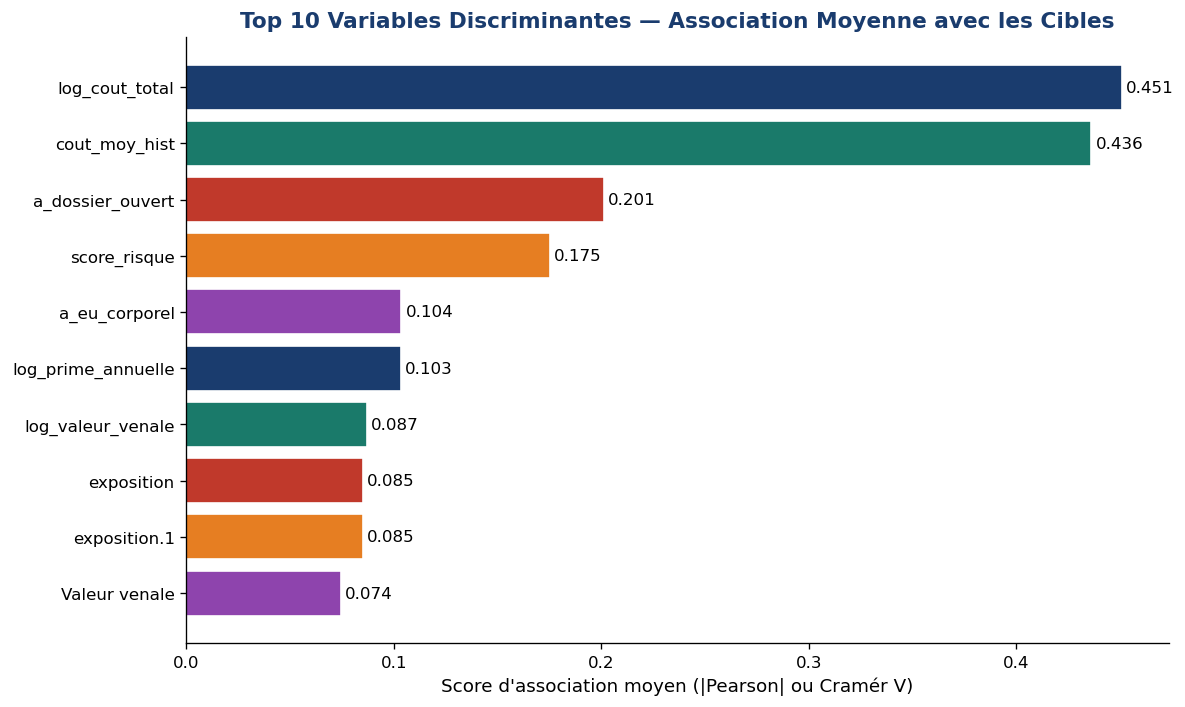

✅ Figure sauvegardée : fig_31_top_variables.png


In [16]:
if results:
    top_vars = (df_assoc.groupby('variable')['association']
                .mean().sort_values(ascending=False).head(10))

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = [PALETTE[i % 5] for i in range(len(top_vars))]
    bars = ax.barh(top_vars.index[::-1], top_vars.values[::-1], color=colors[::-1], edgecolor='white')
    for bar, val in zip(bars, top_vars.values[::-1]):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=10)
    ax.set_title('Top 10 Variables Discriminantes — Association Moyenne avec les Cibles',
                 fontweight='bold', color=C1)
    ax.set_xlabel('Score d\'association moyen (|Pearson| ou Cramér V)')
    plt.tight_layout()
    plt.savefig('fig_31_top_variables.png', bbox_inches='tight', dpi=120)
    plt.show()
    print('✅ Figure sauvegardée : fig_31_top_variables.png')

## 9. Insights Métier — Segments les Plus Risqués

Synthèse des observations clés issues de l'analyse exploratoire.  
Ces insights documentent les **hypothèses actuarielles** qui seront utilisées dans tous les modules suivants.

In [17]:
print('=' * 65)
print('  ACTUWISE — Module 3.1 : INSIGHTS MÉTIER')
print('=' * 65)

# ── Fréquence ─────────────────────────────────────────────────────────
if col_bin:
    taux_sin = df_freq[col_bin].mean() * 100
    print(f'\n📊 FRÉQUENCE')
    print(f'   Taux de sinistralité global      : {taux_sin:.1f}% des polices')

if col_nb:
    lambda_hat = df_freq[col_nb].mean()
    print(f'   Nombre moyen de sinistres/police  : {lambda_hat:.4f} (λ̂ Poisson)')
    print(f'   Polices multi-sinistres (≥2)      : {(df_freq[col_nb]>=2).sum():,} ({(df_freq[col_nb]>=2).mean()*100:.1f}%)')

# ── Sévérité ──────────────────────────────────────────────────────────
if col_sev:
    print(f'\n💰 SÉVÉRITÉ')
    data_sev = df_sev[col_sev].dropna()
    data_sev = data_sev[data_sev > 0]
    print(f'   Coût moyen des sinistres          : {data_sev.mean():,.0f} DT')
    print(f'   Médiane                           : {data_sev.median():,.0f} DT')
    print(f'   Sinistres graves (>P95)           : {(data_sev > data_sev.quantile(0.95)).sum():,} ({5:.0f}% des sinistres)')
    print(f'   Concentration : les 5% sinistres les plus graves représentent')
    top5_share = data_sev[data_sev > data_sev.quantile(0.95)].sum() / data_sev.sum() * 100
    print(f'   {top5_share:.1f}% du coût total des sinistres')

# ── Loss ratio ────────────────────────────────────────────────────────
if col_lr:
    print(f'\n📈 LOSS RATIO & RATIO COMBINÉ BRUT')
    lr_mean = df_freq[col_lr].mean()
    rc_mean = lr_mean + RATIO_FRAIS
    print(f'   Loss ratio moyen global           : {lr_mean*100:.1f}%')
    print(f'   Ratio combiné brut moyen          : {rc_mean*100:.1f}% (frais forfait {RATIO_FRAIS*100:.0f}%)')
    status = '🔴 PERTE TECHNIQUE' if rc_mean > 1.0 else ('🟡 ALERTE' if rc_mean > 0.95 else '🟢 RENTABLE')
    print(f'   Statut global                     : {status}')

# ── Segments à risque ─────────────────────────────────────────────────
if col_lr and segs_disponibles:
    print(f'\n🎯 TOP 3 SEGMENTS À RISQUE (loss ratio le plus élevé)')
    for seg in segs_disponibles:
        top3 = df_freq.groupby(seg)[col_lr].mean().sort_values(ascending=False).head(3)
        print(f'\n   Par {seg} :')
        for val, lr in top3.items():
            rc = lr + RATIO_FRAIS
            flag = '🔴' if rc > 1.0 else ('🟡' if rc > 0.95 else '🟢')
            print(f'     {flag} {str(val):<20} → Loss ratio = {lr*100:.1f}% | RC brut = {rc*100:.1f}%')

print('\n' + '=' * 65)
print('→ Ces insights alimentent les hypothèses du Notebook 3.2 (GLM)')
print('=' * 65)

  ACTUWISE — Module 3.1 : INSIGHTS MÉTIER

📊 FRÉQUENCE
   Taux de sinistralité global      : 49.0% des polices
   Nombre moyen de sinistres/police  : 1.1118 (λ̂ Poisson)
   Polices multi-sinistres (≥2)      : 25,713 (27.1%)

💰 SÉVÉRITÉ
   Coût moyen des sinistres          : 1,084 DT
   Médiane                           : 280 DT
   Sinistres graves (>P95)           : 1,991 (5% des sinistres)
   Concentration : les 5% sinistres les plus graves représentent
   47.5% du coût total des sinistres

📈 LOSS RATIO & RATIO COMBINÉ BRUT
   Loss ratio moyen global           : 59.9%
   Ratio combiné brut moyen          : 84.9% (frais forfait 25%)
   Statut global                     : 🟢 RENTABLE

🎯 TOP 3 SEGMENTS À RISQUE (loss ratio le plus élevé)

   Par Usage_Promenade et affaire :
     🟢 1                    → Loss ratio = 61.4% | RC brut = 86.4%
     🟢 0                    → Loss ratio = 53.4% | RC brut = 78.4%

   Par Energie_Essence :
     🟢 1                    → Loss ratio = 62.3% | RC brut

## 10. Tableau Récapitulatif — KPIs Clés du Module 3.1

Ce tableau synthétique est produit pour référence dans les notebooks suivants.

In [18]:
kpis = {}

if col_bin: kpis['Taux sinistralité (%)'] = round(df_freq[col_bin].mean() * 100, 2)
if col_nb:  kpis['λ̂ moyen Poisson']       = round(df_freq[col_nb].mean(), 4)
if col_sev:
    kpis['Coût moyen sinistres (DT)']  = round(df_sev[col_sev].dropna().mean(), 0)
    kpis['Médiane sévérité (DT)']      = round(df_sev[col_sev].dropna().median(), 0)
if col_lr:
    kpis['Loss ratio global (%)']      = round(df_freq[col_lr].mean() * 100, 1)
    kpis['Ratio combiné brut (%)']     = round((df_freq[col_lr].mean() + RATIO_FRAIS) * 100, 1)
if col_expo:
    kpis['Exposition totale (ann.-véh.)'] = round(df_freq[col_expo].sum(), 0)

kpis['N polices (fréquence)'] = len(df_freq)
kpis['N sinistres (sévérité)'] = len(df_sev)

df_kpis = pd.DataFrame.from_dict(kpis, orient='index', columns=['Valeur'])
df_kpis.index.name = 'KPI'

print('=' * 50)
print('  ACTUWISE — Module 3.1 — KPIs Récapitulatifs')
print('=' * 50)
print(df_kpis.to_string())
df_kpis.to_csv('kpis_module_31.csv')
print('\n✅ KPIs exportés → kpis_module_31.csv')

  ACTUWISE — Module 3.1 — KPIs Récapitulatifs
                                    Valeur
KPI                                       
Taux sinistralité (%)              49.0400
λ̂ moyen Poisson                    1.1118
Coût moyen sinistres (DT)        1084.0000
Médiane sévérité (DT)             280.0000
Loss ratio global (%)              59.9000
Ratio combiné brut (%)             84.9000
Exposition totale (ann.-véh.)  322697.0000
N polices (fréquence)           94846.0000
N sinistres (sévérité)          39873.0000

✅ KPIs exportés → kpis_module_31.csv


## 11. Livrables pour le Notebook 3.2

Ce notebook a produit les éléments suivants, directement exploitables par le **Notebook 3.2 (GLM Baseline)** :

| Livrable | Format | Destination |
|----------|--------|-------------|
| `kpis_module_31.csv` | CSV | Tableau de bord Module 3.6 |
| `fig_31_frequence_distribution.png` | PNG | Rapport |
| `fig_31_severite_distribution.png` | PNG | Rapport |
| `fig_31_loss_ratio_segments.png` | PNG | Rapport |
| `fig_31_ratio_combine.png` | PNG | Module 3.6 + Power BI |
| `fig_31_correlations.png` | PNG | Rapport |
| `fig_31_top_variables.png` | PNG | Notebook 3.2 — sélection features |

**Ce que le Notebook 3.2 va faire avec ces résultats :**
- Les **top variables discriminantes** identifiées ici seront utilisées comme features du GLM Poisson et GLM Gamma
- La valeur de **λ̂ moyen** servira de référence pour valider les prédictions GLM
- Les **segments à risque** identifiés ici seront confirmés (ou infirmés) par les coefficients GLM

---
*ACTUWISE — Notebook 3.1 terminé ✅*